# **02 · Feature Engineering**
**Project**: Retail Revenue Forecasting — Olist Brazil E-commerce

**Mục tiêu notebook này:**
- Tạo lag features, rolling features, calendar features, holiday flags
- Visualize từng nhóm feature để hiểu ý nghĩa
- Build feature matrix sẵn sàng cho modeling
- Thực hiện RFM & Cohort Analysis (twist tạo điểm khác biệt)

## 0. Setup

In [1]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from src.data_loader import load_raw_tables, build_master_df, build_daily_series
from src.features import (
    add_lag_features, add_rolling_features,
    add_calendar_features, add_holiday_features,
    build_feature_matrix, compute_rfm, compute_cohort,
    FEATURE_COLS, TARGET_COL
)

IMAGES_DIR = Path("../images")
DATA_DIR   = "../data/"

In [2]:
tables = load_raw_tables(DATA_DIR)
df     = build_master_df(tables)
daily  = build_daily_series(df)

## 1. Lag Features

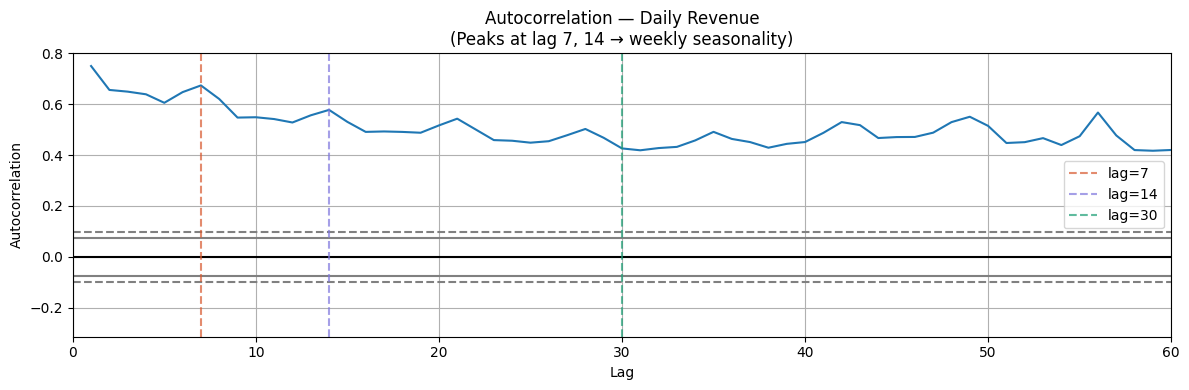

In [3]:
from pandas.plotting import autocorrelation_plot

fig, ax = plt.subplots(figsize=(12, 4))
autocorrelation_plot(daily["revenue"], ax=ax)
ax.set_xlim(0, 60)
ax.set_title("Autocorrelation — Daily Revenue\n(Peaks at lag 7, 14 → weekly seasonality)", fontsize=12)
ax.axvline(7,  color="#D85A30", linestyle="--", alpha=0.7, label="lag=7")
ax.axvline(14, color="#7F77DD", linestyle="--", alpha=0.7, label="lag=14")
ax.axvline(30, color="#1D9E75", linestyle="--", alpha=0.7, label="lag=30")
ax.legend()
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "autocorrelation.png", dpi=150, bbox_inches="tight")


* ###  Add lag features

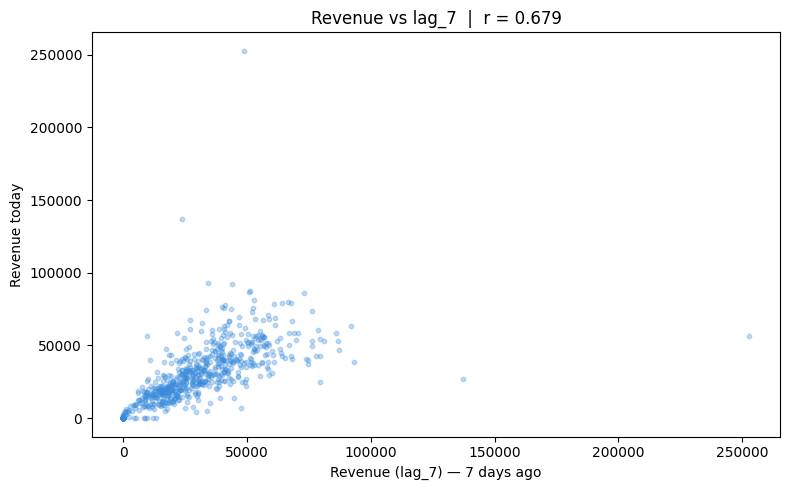

In [4]:

daily_lag = add_lag_features(daily, lags=[7, 14, 30])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(daily_lag["lag_7"], daily_lag["revenue"], alpha=0.3, s=10, color="#378ADD")
ax.set_xlabel("Revenue (lag_7) — 7 days ago")
ax.set_ylabel("Revenue today")
ax.set_title(f"Revenue vs lag_7  |  r = {daily_lag['revenue'].corr(daily_lag['lag_7']):.3f}")
plt.tight_layout()
plt.show(
# plt.savefig(IMAGES_DIR / "lag7_scatter.png", dpi=150, bbox_inches="tight")
)

## 2. Rolling Features

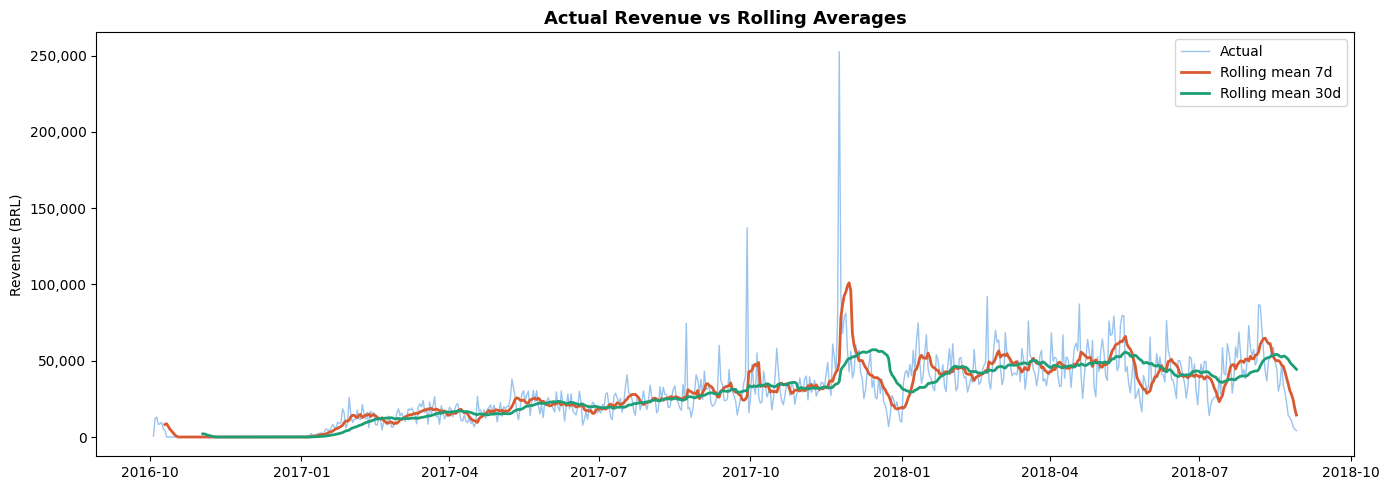

In [5]:
daily_rolling = add_rolling_features(daily_lag, windows=[7, 14, 30])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_rolling["date"], daily_rolling["revenue"],
        alpha=0.5, color="#378ADD", linewidth=1, label="Actual")
ax.plot(daily_rolling["date"], daily_rolling["rolling_mean_7"],
        color="#D85A30", linewidth=2, label="Rolling mean 7d")
ax.plot(daily_rolling["date"], daily_rolling["rolling_mean_30"],
        color="#1D9E75", linewidth=2, label="Rolling mean 30d")
ax.set_title("Actual Revenue vs Rolling Averages", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (BRL)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "rolling_averages.png", dpi=150, bbox_inches="tight")


## 3. Calendar & Holiday Features

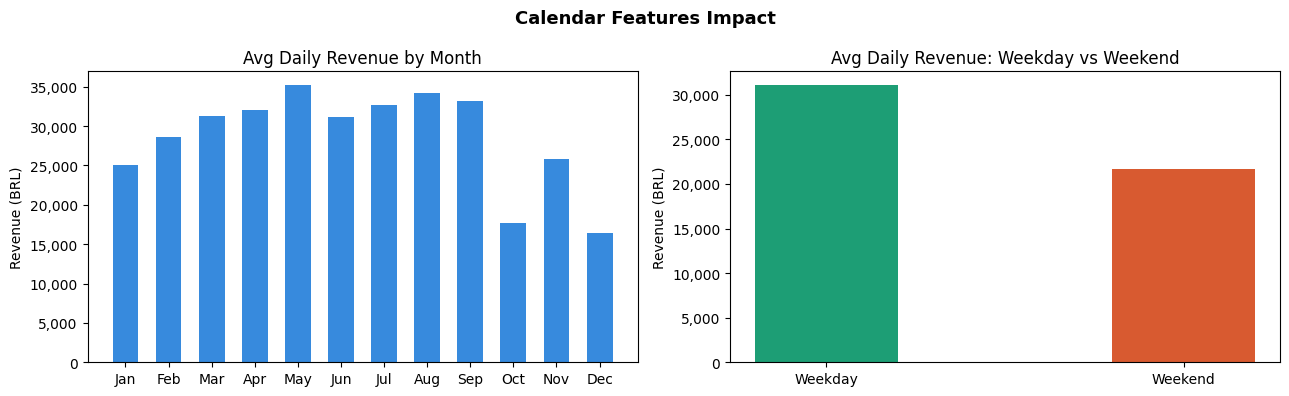

In [6]:
daily_cal = add_calendar_features(daily_rolling)
daily_all = add_holiday_features(daily_cal)

# Revenue trung bình theo month
monthly_avg = daily_all.groupby("month")["revenue"].mean()
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(month_names, monthly_avg.values, color="#378ADD", width=0.6)
axes[0].set_title("Avg Daily Revenue by Month")
axes[0].set_ylabel("Revenue (BRL)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Weekend vs weekday
wk_comp = daily_all.groupby("is_weekend")["revenue"].mean()
axes[1].bar(["Weekday", "Weekend"], wk_comp.values, color=["#1D9E75", "#D85A30"], width=0.4)
axes[1].set_title("Avg Daily Revenue: Weekday vs Weekend")
axes[1].set_ylabel("Revenue (BRL)")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

plt.suptitle("Calendar Features Impact", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "calendar_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
holiday_comp = daily_all.groupby("is_holiday")["revenue"].mean()
print("Revenue on holidays vs normal days:")
print(f"  Normal days  : {holiday_comp[0]:,.0f} BRL")
print(f"  Holiday days : {holiday_comp[1]:,.0f} BRL")
print(f"  Difference   : {(holiday_comp[1]/holiday_comp[0] - 1)*100:+.1f}%")

Revenue on holidays vs normal days:
  Normal days  : 28,409 BRL
  Holiday days : 28,608 BRL
  Difference   : +0.7%


## 4. Feature Matrix

In [8]:
feature_df = build_feature_matrix(daily)

print(f"\nFinal feature matrix shape: {feature_df.shape}")
print(f"\nCorrelation với target 'revenue':")
corr = feature_df[FEATURE_COLS + [TARGET_COL]].corr()[TARGET_COL].drop(TARGET_COL)
print(corr.sort_values(ascending=False).apply(lambda x: f"{x:.3f}").to_string())

Feature matrix: 666 rows × 25 cols
Features: ['lag_7', 'lag_14', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14', 'rolling_mean_30', 'rolling_std_30', 'month', 'quarter', 'dayofweek', 'day', 'is_weekend', 'days_to_month_end', 'week_of_year', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'is_holiday', 'is_pre_holiday', 'is_post_holiday']

Final feature matrix shape: (666, 25)

Correlation với target 'revenue':
rolling_mean_7        0.765
rolling_mean_14       0.734
rolling_mean_30       0.697
lag_7                 0.661
lag_14                0.573
rolling_std_7         0.492
rolling_std_30        0.472
lag_30                0.458
dayofweek_sin         0.173
days_to_month_end     0.020
dayofweek_cos         0.013
is_holiday            0.006
month_sin            -0.020
is_post_holiday      -0.023
is_pre_holiday       -0.047
quarter              -0.066
week_of_year         -0.079
month_cos            -0.189
is_weekend           -0.207


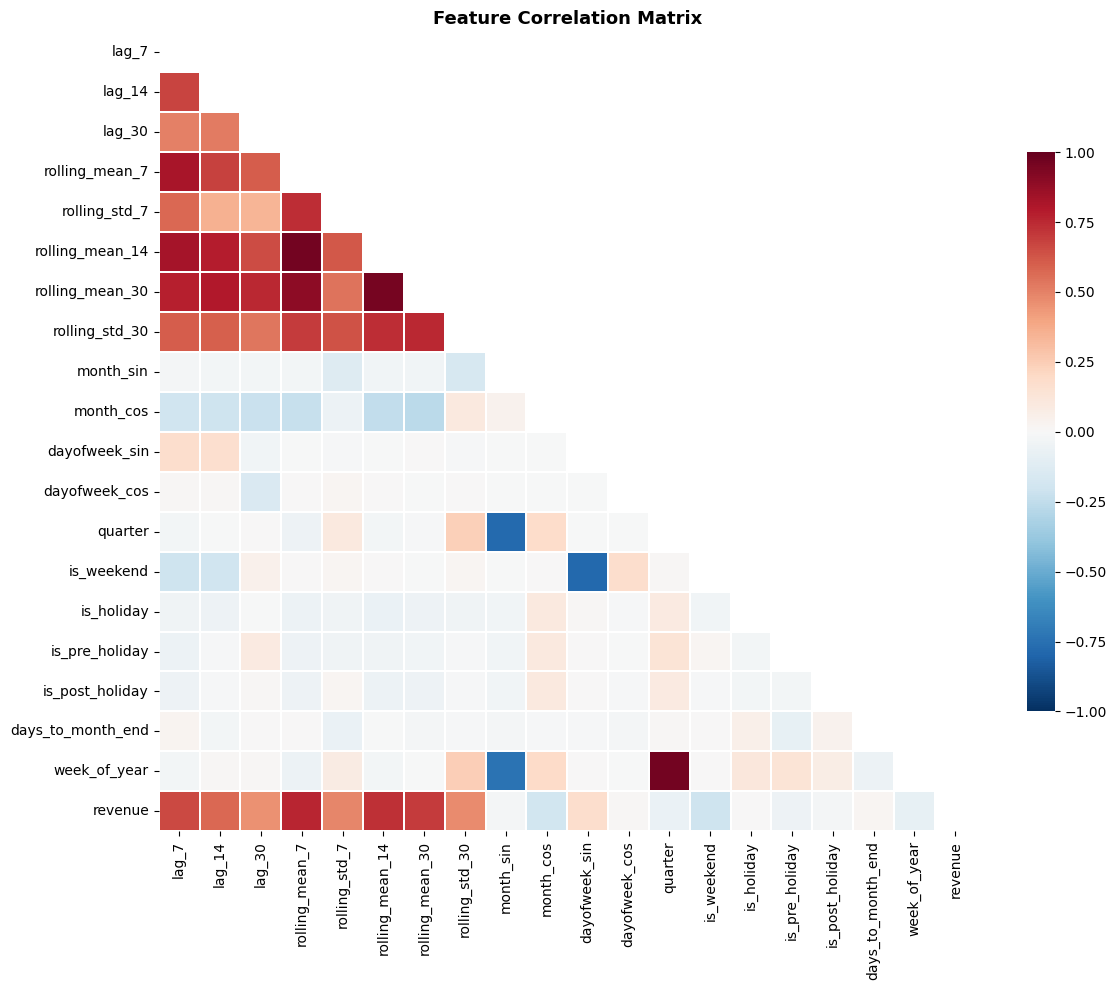

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = feature_df[FEATURE_COLS + [TARGET_COL]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, ax=ax, annot=False, linewidths=0.3,
    cbar_kws={"shrink": 0.7}
)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")


## 5. RFM Analysis — Customer Segmentation


=== RFM Summary ===
segment
At Risk            24083
Loyal              23891
Needs Attention    18035
Champions          12365
Recent             12114
Lost                5989


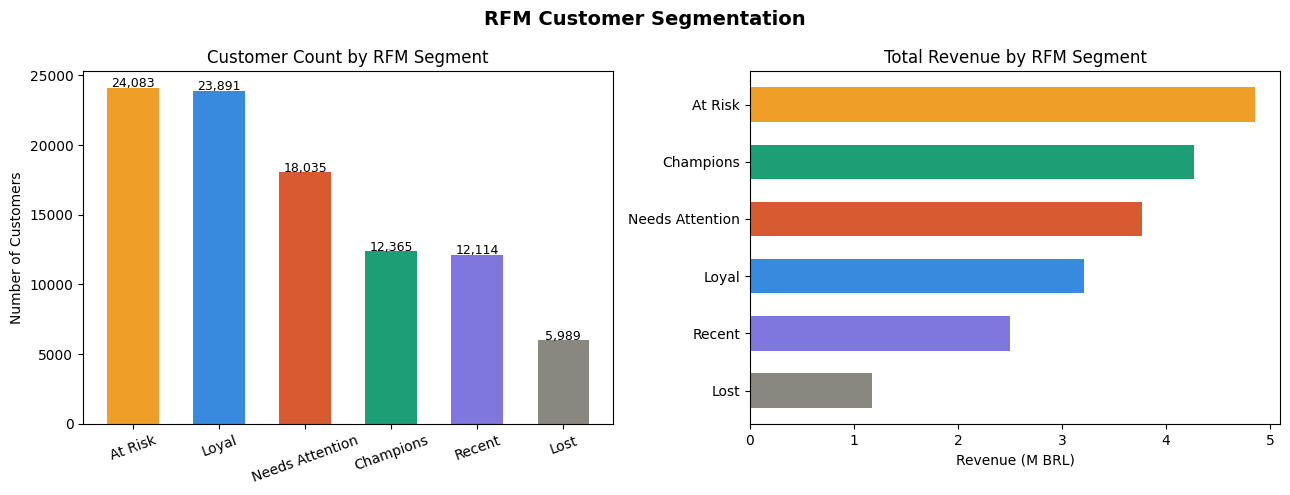

In [10]:
rfm = compute_rfm(df)

seg_counts = rfm["segment"].value_counts()
colors_map = {
    "Champions":      "#1D9E75",
    "Loyal":          "#378ADD",
    "Recent":         "#7F77DD",
    "At Risk":        "#EF9F27",
    "Needs Attention":"#D85A30",
    "Lost":           "#888780",
}
colors = [colors_map.get(s, "#888780") for s in seg_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
axes[0].bar(seg_counts.index, seg_counts.values, color=colors, width=0.6)
axes[0].set_title("Customer Count by RFM Segment")
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis="x", rotation=20)
for i, (idx, val) in enumerate(seg_counts.items()):
    axes[0].text(i, val + 50, f"{val:,}", ha="center", fontsize=9)

# Revenue by segment
rev_by_seg = rfm.groupby("segment")["monetary"].sum().sort_values(ascending=True)
rev_colors = [colors_map.get(s, "#888780") for s in rev_by_seg.index]
axes[1].barh(rev_by_seg.index, rev_by_seg.values / 1e6, color=rev_colors, height=0.6)
axes[1].set_title("Total Revenue by RFM Segment")
axes[1].set_xlabel("Revenue (M BRL)")

plt.suptitle("RFM Customer Segmentation", fontsize=14, fontweight="bold")
plt.tight_layout()
# plt.savefig(IMAGES_DIR / "rfm_segments.png", dpi=150, bbox_inches="tight")
plt.show()

* ###  RFM scatter: Recency vs Monetary, colored by segment

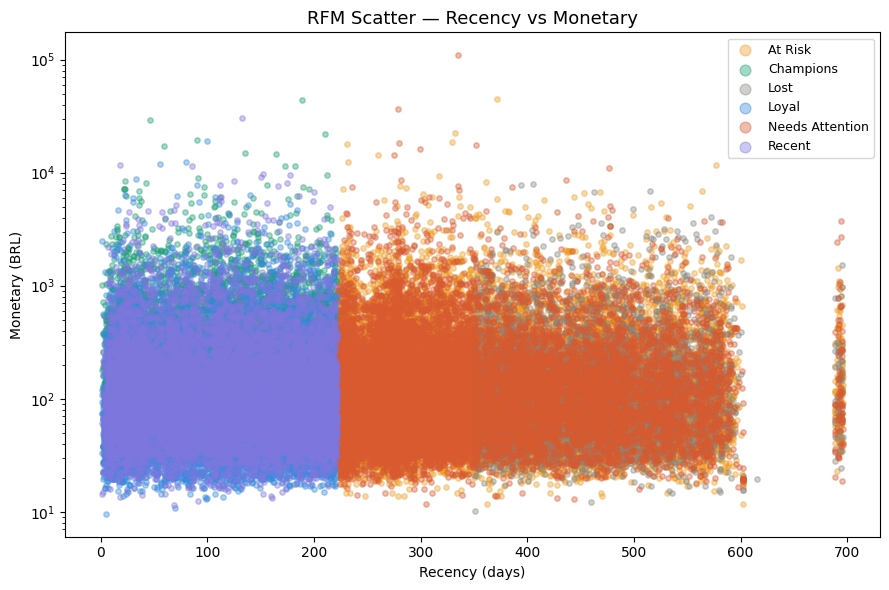

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
for seg, group in rfm.groupby("segment"):
    ax.scatter(
        group["recency"], group["monetary"],
        label=seg, alpha=0.4, s=15,
        color=colors_map.get(seg, "#888780"),
    )
ax.set_xlabel("Recency (days)")
ax.set_ylabel("Monetary (BRL)")
ax.set_title("RFM Scatter — Recency vs Monetary", fontsize=13)
ax.legend(markerscale=2, fontsize=9)
ax.set_yscale("log")
plt.tight_layout()
plt.show()
# plt.savefig(IMAGES_DIR / "rfm_scatter.png", dpi=150, bbox_inches="tight")
